In [1]:
import matplotlib.gridspec as gridspec
from utils_models import *

In [2]:

def plot_fluxonium_transitions(ax,matrix, energies,xlim,ylim = (2e-3,0.8)):
    from random import random 
    k = len(energies)  # Assuming matrix is k x k and energies is a list of length k

    label_positions = []

    def check_collision_and_direction(new_pos, existing_positions, x_threshold=1.5, y_threshold=0.1):
        for pos in existing_positions:
            dx = new_pos[0] - pos[0]
            dy = np.log10(new_pos[1]) - np.log10(pos[1])
            if abs(dx)<0.5:
                if dy < y_threshold and dy >= 0:
                    print('detected')
                    return 1
                elif dy > -1* y_threshold and dy <= 0:
                    print('detected')
                    return -1
                    
        return False


    for i in range(3):
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element

                ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o', color='grey', markersize=4)

                if element_ij >= ylim[0]:
                    x_loc = freq_ij  - 0.1
                    y_loc = element_ij+0.003
                    text_pos = (x_loc, y_loc)


                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        ax.text(*(x_loc,y_loc), rf'{i}-{j}', size=9)
                        label_positions.append(text_pos)
                    else:
                        # print(f'omitted: {i}-{j}')
                        pass
    plt.text(-0.07, 1, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')

    ax.set_ylabel(r'$\langle i | \hat{n} | j \rangle$')
    # ax.set_xlabel(r'transition frequency $\omega_{ij}$')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.set_xlim(xlim)
    # ax.set_yscale('log')
    # ax.set_ylim(ylim)

colors = [(0.7, 0.6, 0.0), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]


Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 97500.46it/s]
 /tmp/ipykernel_85957/2647360731.py: 35

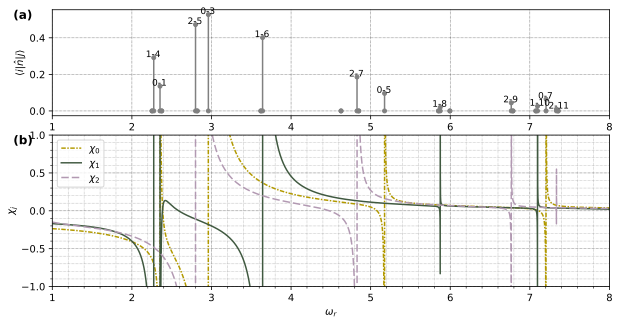

In [8]:
def plot_sweep_Er(ax,elements, evals,Er_list,qls = [0,1,2]):
    num_evals =len(evals)

    for ql , color, linestyle in zip(qls, colors, linestyles):
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(elements[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts))
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    plt.text(-0.07, 1, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(-1,1)
    
    ax.set_xlabel(rf'$\omega_r$')
    ax.set_ylabel(r'$\chi_{j}$')
    ax.legend(loc = 'upper left')


n_evals = 20

qbt = scqubits.Fluxonium(EJ = 2.65,EC = 0.6,EL = 0.13, cutoff = 110,flux = 0,truncated_dim=20)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(1,8,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2])

plt.tight_layout()
plt.show()